# 8. Утилиты библиотеки: встроенные графики, загрузка и обработка пропусков

**Цель:** показать возможности `graph-evt-agent`, которые нигде в ноутбуках 1–7 ещё не использовались, хотя доступны и для одномерного входа: загрузчик `load_csv`/`TimeSeriesInput`, `progress_callback` вместо tqdm, встроенные графики `plot_detection`/`plot_evaluation` и политики обработки пропусков `InputConfig(missing=...)`. Это обзор инструментов, а не новый анализ; выводы о самом ряде из ноутбуков 1–7 не меняются.

## 1. Загрузка через библиотеку vs pandas

`load_csv` — универсальный CSV-ридер: он превращает **каждую** колонку, кроме определённой по имени временной (`time`/`timestamp`/`datetime`/`date_time`), в отдельный канал. У `fractal_extreme_series.csv`, помимо `value`, есть служебная колонка `is_extreme` — наивный вызов `load_csv` на сырой файл поэтому превратит одномерный ряд в двухканальный вход. Это не баг загрузчика, а зона ответственности вызывающего кода: у `load_csv` нет понятия "это метка, а не сигнал".

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from graph_evt_agent import load_csv
from graph_evt_agent.input import TimeSeriesInput

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/fractal_extreme_series.csv").exists())
DATA = ROOT / "data/generated/fractal_extreme_series.csv"
SEED = 42

naive = load_csv(DATA)
print(f"naive load_csv(DATA): {np.asarray(naive.values).shape} -> channels {naive.channel_names}")

df = pd.read_csv(DATA)
x = df["value"].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)
true_onset = int(np.flatnonzero(event_mask)[0])

# Correct usage: build TimeSeriesInput from only the signal column.
ts_input = TimeSeriesInput(values=x, timestamps=df["timestamp"].to_numpy(), channel_names=("value",))
print(f"corrected TimeSeriesInput: {np.asarray(ts_input.values).shape} -> channel {ts_input.channel_names}")

naive load_csv(DATA): (1500, 2) -> channels ('value', 'is_extreme')
corrected TimeSeriesInput: (1500,) -> channel ('value',)


`GraphEVTPipeline.run_detailed` accepts a `TimeSeriesInput` directly (it dispatches on type the same way it dispatches a file path), so from here on we pass `ts_input` instead of the raw `x` array used in ноутбуках 1–7 — same values, but going through the library's own container instead of a bare NumPy array.

## 2. Пользовательский `progress_callback` вместо tqdm

`verbose=True` рисует tqdm-полосу в stderr — удобно интерактивно, но её нельзя разобрать программно. `progress_callback` получает те же обновления как объекты `ProgressEvent(desc, step, total, message, elapsed)` — то, на чём можно построить логирование, GUI или прогресс в web-сервисе.

In [2]:
from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, InputConfig

BASELINE_SIZE = true_onset  # oracle-assisted, as in notebooks 3-7
evt_config = EVTConfig(baseline_size=BASELINE_SIZE, tail_quantile=0.95, alarm_probability=0.999, persistence=3)

progress_events = []
pipeline = GraphEVTPipeline(
    evt_config,
    graph=GraphConfig(random_state=SEED),
    input_config=InputConfig(missing="error"),
    verbose=False,
    progress_callback=progress_events.append,
)
result = pipeline.run_detailed(ts_input)

pd.DataFrame([
    {"step": e.step, "total": e.total, "message": e.message, "elapsed_s": round(e.elapsed, 4)}
    for e in progress_events
])

,step,total,message,elapsed_s
0,1,3,"input univariate (1500, 1)",0.0000
1,2,3,stationary baseline,0.0000
2,3,3,event at 619,0.0046
3,3,3,stop: single_channel_cannot_localize,0.0046


## 3. Встроенный `plot_detection` vs собственная визуализация (ноутбук 3)

Библиотека сама умеет строить базовую фигуру детекции одним вызовом. Сравним её с нашей версией из ноутбука 3, которая добавляет знание об истинном интервале события — то, чего у самой библиотеки нет.

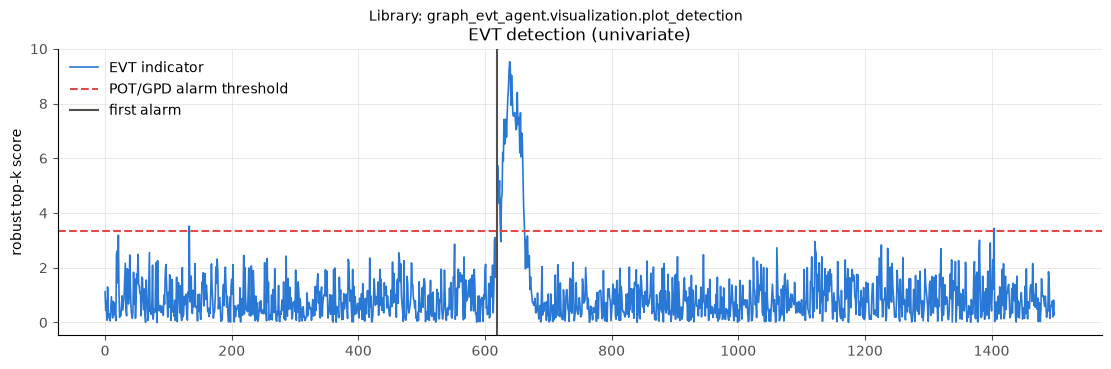

In [3]:
import matplotlib.pyplot as plt
from graph_evt_agent import visualization as gviz

fig_builtin = gviz.plot_detection(result, timestamps=df["timestamp"].to_numpy())
fig_builtin.suptitle("Library: graph_evt_agent.visualization.plot_detection", fontsize=10, y=1.04)
plt.show()

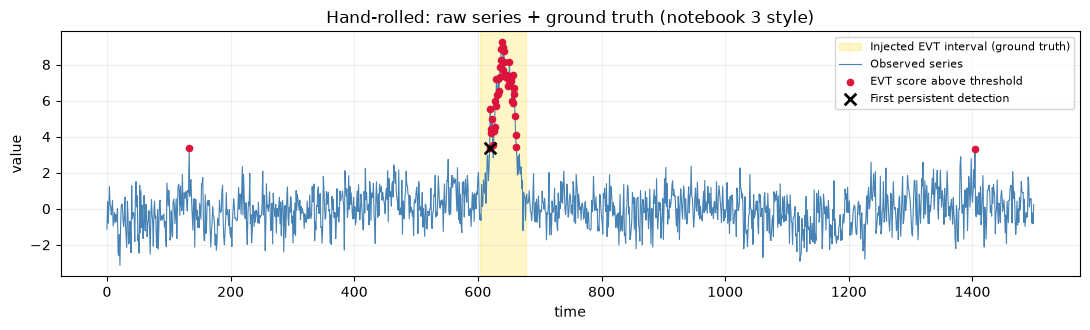

In [4]:
detection = result.detection
above_alarm = detection.indicator > detection.alarm_threshold
event_end = int(np.flatnonzero(event_mask)[-1])

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axvspan(df["timestamp"].iloc[true_onset], df["timestamp"].iloc[event_end], color="gold", alpha=0.22,
           label="Injected EVT interval (ground truth)")
ax.plot(df["timestamp"], x, color="steelblue", linewidth=0.8, label="Observed series")
ax.scatter(df.loc[above_alarm, "timestamp"], x[above_alarm], color="crimson", s=20, zorder=3,
           label="EVT score above threshold")
if detection.time_index is not None:
    ax.scatter(df["timestamp"].iloc[detection.time_index], x[detection.time_index], color="black",
               marker="x", s=70, linewidth=2, zorder=4, label="First persistent detection")
ax.set(title="Hand-rolled: raw series + ground truth (notebook 3 style)", xlabel="time", ylabel="value")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

Встроенный график быстр и единообразен между всеми ноутбуками, использующими библиотеку, но рисует только то, что видит сам pipeline — индикатор и порог. Он не знает о разметке `is_extreme`, потому что EVT-детектор её не получает. Наш вариант рисует сырой ряд и подсвечивает истинный интервал события, потому что этим знанием владеем мы, а не библиотека. Нижняя панель `plot_detection` (source ranking) появляется только когда `result.ranking is not None` — для 1-D она отсутствует, и фигура выше рисует единственную панель.

## 4. Встроенный `plot_evaluation` для отчёта EvaluationOrchestrator

В ноутбуке 7 результат `EvaluationOrchestrator.evaluate(...)` мы только печатали как словарь и `DataFrame`. Библиотека умеет визуализировать тот же объект отчёта одним вызовом.

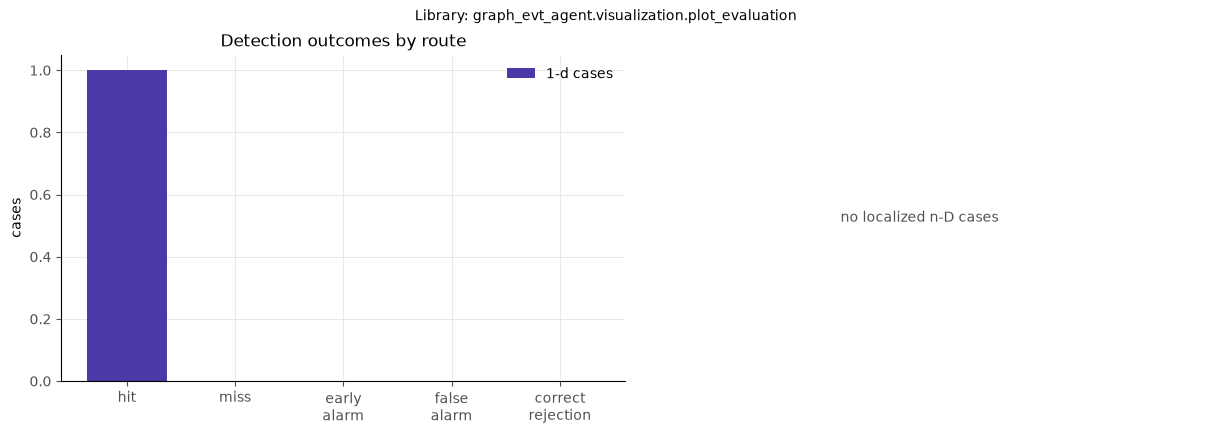

,case_id,route,outcome,stop_reason,detected_time,true_event_time,delay,true_source,heuristic_source,heuristic_rank,gnn_source,gnn_rank,gat_source,gat_rank
0,fractal 1-D,1-d,hit,single_channel_cannot_localize,619,604,15,None,None,None,None,None,None,None


In [5]:
from graph_evt_agent import EvaluationCase, EvaluationOrchestrator

evaluation = EvaluationOrchestrator(pipeline, early_tolerance=0, k=3, verbose=False).evaluate([
    EvaluationCase(ts_input, event_time=true_onset, case_id="fractal 1-D"),
])

fig_eval = gviz.plot_evaluation(evaluation)
fig_eval.suptitle("Library: graph_evt_agent.visualization.plot_evaluation", fontsize=10, y=1.05)
plt.show()
pd.DataFrame(evaluation.to_records())

Левая панель — единственная содержательная часть для этого набора: один `1-d`-случай, исход `hit`. Правая панель честно сообщает "no localized n-D cases", потому что Top-k/MRR определены только для локализации источника в многоканальном случае — на чисто 1-D наборе такой локализации не существует, и график не подделывает несуществующую метрику.

## 5. Обработка пропусков: `InputConfig(missing=...)`

Этот CSV не содержит пропусков, поэтому `InputInspector` с `missing="error"` (default, используемый в ноутбуках 1–7) никогда не срабатывает. Внесём синтетические пропуски и покажем все три политики.

In [6]:
rng = np.random.default_rng(SEED)
gap_fraction = 0.03
gap_indices = np.sort(rng.choice(len(x), size=int(gap_fraction * len(x)), replace=False))
x_with_gaps = x.copy()
x_with_gaps[gap_indices] = np.nan
print(f"Injected {len(gap_indices)} synthetic gaps ({gap_fraction:.0%} of {len(x)} points)")

Injected 45 synthetic gaps (3% of 1500 points)


In [7]:
from graph_evt_agent.input import InputInspector

rows = []
for policy in ("error", "drop_rows", "interpolate"):
    inspector = InputInspector(InputConfig(missing=policy))
    gapped_input = TimeSeriesInput(x_with_gaps, df["timestamp"].to_numpy(), ("value",))
    try:
        prepared = inspector.inspect(gapped_input)
        rows.append({
            "policy": policy, "outcome": "ok", "n_time": prepared.profile.n_time,
            "missing_per_channel": prepared.profile.missing_per_channel.tolist(),
            "regular_time": prepared.profile.regular_time, "actions": prepared.profile.actions,
        })
    except ValueError as error:
        rows.append({"policy": policy, "outcome": f"ValueError: {error}", "n_time": None,
                     "missing_per_channel": None, "regular_time": None, "actions": None})
pd.DataFrame(rows)

,policy,outcome,n_time,missing_per_channel,regular_time,actions
0,error,ValueError: input contains 45 missing/non-fini...,NaN,None,None,None
1,drop_rows,ValueError: irregular timestamps require resam...,NaN,None,None,None
2,interpolate,ok,1500.0,[45],True,"(interpolated_missing_values,)"


`drop_rows` raises here too — but for a different reason than `error`. Dropping 45 scattered rows leaves an irregular time axis, and `require_regular_time=True` (the default) rejects that *after* the drop. Passing `require_regular_time=False` as well is what actually lets `drop_rows` through:

In [8]:
prepared_dropped = InputInspector(
    InputConfig(missing="drop_rows", require_regular_time=False)
).inspect(TimeSeriesInput(x_with_gaps, df["timestamp"].to_numpy(), ("value",)))
print(f"drop_rows + require_regular_time=False: n_time={prepared_dropped.profile.n_time} "
      f"(was {len(x)}), regular_time={prepared_dropped.profile.regular_time}, "
      f"actions={prepared_dropped.profile.actions}")

drop_rows + require_regular_time=False: n_time=1455 (was 1500), regular_time=False, actions=('dropped_rows_with_missing_values',)


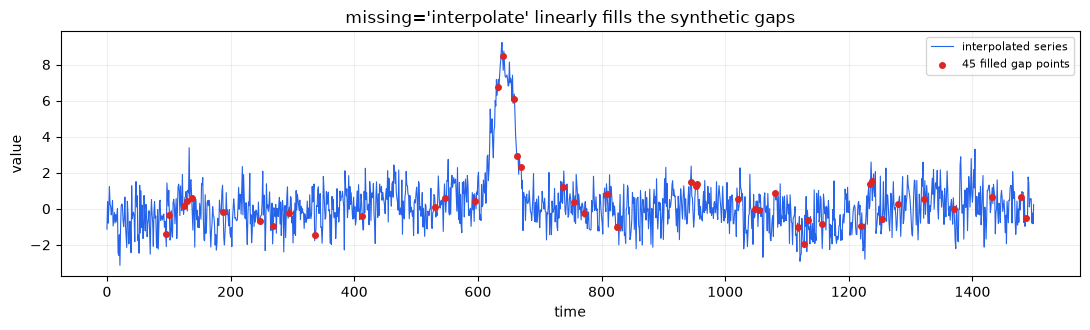

In [9]:
interpolated = InputInspector(InputConfig(missing="interpolate")).inspect(
    TimeSeriesInput(x_with_gaps, df["timestamp"].to_numpy(), ("value",))
).values[:, 0]

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(df["timestamp"], interpolated, color="#2563eb", linewidth=0.8, label="interpolated series")
ax.scatter(df["timestamp"].iloc[gap_indices], interpolated[gap_indices], color="#dc2626", s=16, zorder=3,
           label=f"{len(gap_indices)} filled gap points")
ax.set(title="missing='interpolate' linearly fills the synthetic gaps", xlabel="time", ylabel="value")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

Наконец прогоним полный `GraphEVTPipeline` прямо на ряде с пропусками, используя `missing="interpolate"` — не как изолированную проверку `InputInspector`, а как реальную конфигурацию pipeline.

In [10]:
gapped_pipeline = GraphEVTPipeline(
    evt_config,
    graph=GraphConfig(random_state=SEED),
    input_config=InputConfig(missing="interpolate"),
    verbose=False,
)
gapped_result = gapped_pipeline.run_detailed(
    TimeSeriesInput(x_with_gaps, df["timestamp"].to_numpy(), ("value",))
)
gapped_detection = gapped_result.detection

pd.DataFrame([{
    "gaps_in_baseline": int(np.isnan(x_with_gaps[:BASELINE_SIZE]).sum()),
    "gaps_after_baseline": int(np.isnan(x_with_gaps[BASELINE_SIZE:]).sum()),
    "detected": gapped_detection.detected,
    "time_index": gapped_detection.time_index,
    "delay_vs_true_onset": None if gapped_detection.time_index is None else gapped_detection.time_index - true_onset,
    "delay_on_clean_series": detection.time_index - true_onset if detection.time_index is not None else None,
}])

,gaps_in_baseline,gaps_after_baseline,detected,time_index,delay_vs_true_onset,delay_on_clean_series
0,14,31,True,619,15,15


`missing="interpolate"` держит длину и шаг ряда неизменными и здесь не поменяло результат детекции — но интерполяция это модельное решение, а не восстановление истины: линейная интерполяция сглаживает именно те резкие изменения, которые ищет EVT, и на более плотных или более длинных пропусках может задержать или замаскировать реальное событие. `drop_rows` меняет длину и шаг ряда и требует `require_regular_time=False`, иначе последующая проверка регулярности времени отклонит уже прореженный ряд. `missing="error"` — самый безопасный default для pipeline, который не должен принимать решение о пропусках за вызывающий код.

**Самопроверка:** почему `load_csv` не может сам понять, что `is_extreme` — это метка, а не канал? Почему `progress_callback` полезнее tqdm для встраивания в другой сервис, а не только для интерактивного ноутбука? Что покажет `plot_detection`, если передать ему результат с `result.ranking is not None` (n-D случай из ноутбука 7 `n-d`)? Почему интерполяция пропусков — не нейтральная операция для EVT-анализа, а решение, которое стоит документировать в provenance (ноутбук 6)?